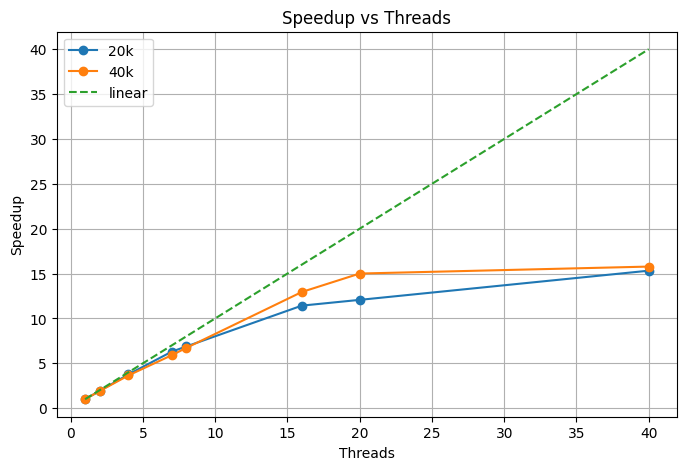

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dgemv/dgemv_time.csv')
df.columns = df.columns.str.strip()

q10 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby(['data_size', 'threads'])['time'].mean().reset_index()
df['speedup'] = df.groupby('data_size')['time'].transform(lambda x: x.iloc[0] / x)
# разбиваем по data_size
df_20k = df[df['data_size'] == 20000]
df_40k = df[df['data_size'] == 40000]

# идеальная линейная линия
threads = sorted(df['threads'].unique())
ideal = threads  # S(p) = p


# plot
plt.figure(figsize=(8, 5))

plt.plot(df_20k['threads'], df_20k['speedup'], marker='o', label='20k')
plt.plot(df_40k['threads'], df_40k['speedup'], marker='o', label='40k')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()

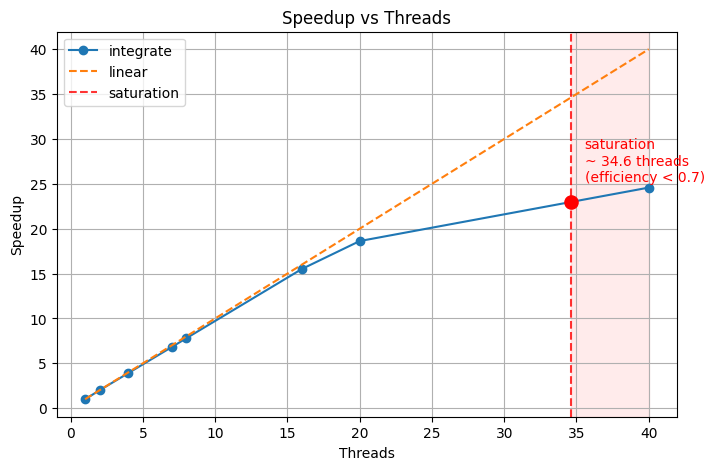

Estimated saturation point: 34.60 threads


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('integrate/integrate_time.csv')
df.columns = df.columns.str.strip()

q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby('threads')['time'].mean().reset_index()

df['speedup'] = df['time'].transform(lambda x: x.iloc[0] / x)

# идеальная линейная линия
threads = df['threads'].to_numpy()
speedup = df['speedup'].to_numpy()
ideal = threads.astype(float)

# относительное отклонение от линейного ускорения:
# D_rel = (p - S(p)) / p = 1 - efficiency
df['rel_deviation'] = (threads - speedup) / threads

# порог насыщения: efficiency < 0.7  <=>  rel_deviation > 0.3
threshold = 0.3

# первый переход через порог
cross_idx = np.where(df['rel_deviation'].to_numpy() > threshold)[0]

p_sat = None
s_sat = None

if len(cross_idx) > 0:
    i2 = cross_idx[0]

    if i2 == 0:
        # если уже первая точка выше порога, интерполировать не с чем
        p_sat = threads[0]
        s_sat = speedup[0]
    else:
        i1 = i2 - 1

        p1, p2 = threads[i1], threads[i2]
        d1, d2 = df.loc[i1, 'rel_deviation'], df.loc[i2, 'rel_deviation']
        s1, s2 = speedup[i1], speedup[i2]

        # линейная интерполяция положения точки насыщения по rel_deviation
        if d2 != d1:
            alpha = (threshold - d1) / (d2 - d1)
            p_sat = p1 + alpha * (p2 - p1)
            s_sat = s1 + alpha * (s2 - s1)
        else:
            p_sat = p2
            s_sat = s2

# plot
plt.figure(figsize=(8, 5))

plt.plot(threads, speedup, marker='o', label='integrate')
plt.plot(threads, ideal, linestyle='--', label='linear')

if p_sat is not None and s_sat is not None:
    plt.axvline(p_sat, color='red', linestyle='--', alpha=0.8, label='saturation')
    plt.scatter(p_sat, s_sat, color='red', s=90, zorder=5)

    plt.annotate(
        f'saturation\n~ {p_sat:.1f} threads\n(efficiency < {1 - threshold})',
        xy=(p_sat, s_sat),
        xytext=(10, 15),
        textcoords='offset points',
        color='red'
    )

    plt.axvspan(p_sat, threads.max(), color='red', alpha=0.08)

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()

if p_sat is not None:
    print(f'Estimated saturation point: {p_sat:.2f} threads')
else:
    print('Saturation point was not detected: rel_deviation never crossed the threshold.')

# SLAE
## Сравнение single omp section и multiple

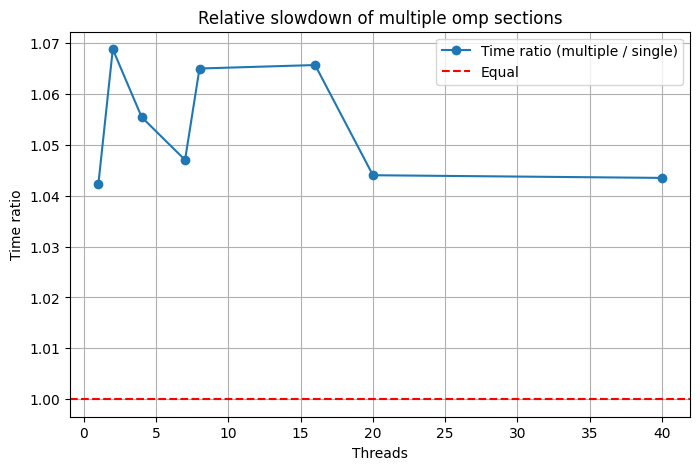

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    df.columns = df.columns.str.strip()

    q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
    q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

    df = df[(df['time'] >= q10) & (df['time'] <= q90)]
    df = df.groupby('threads')['time'].mean().reset_index()

    return df

df_single = pd.read_csv('slae/slae_single_block.csv')
df_multiple = pd.read_csv('slae/slae_multiple_blocks.csv')

df_single = prepare_data(df_single)
df_multiple = prepare_data(df_multiple)

# plot
df = df_single.merge(df_multiple, on='threads', suffixes=('_single', '_multi'))
df['ratio'] = df['time_multi'] / df['time_single']

plt.figure(figsize=(8, 5))
plt.plot(df['threads'], df['ratio'], marker='o', label='Time ratio (multiple / single)')
plt.axhline(1.0, linestyle='--', color='red', label='Equal')

plt.xlabel('Threads')
plt.ylabel('Time ratio')
plt.title('Relative slowdown of multiple omp sections')
plt.legend()
plt.grid(True)

plt.show()

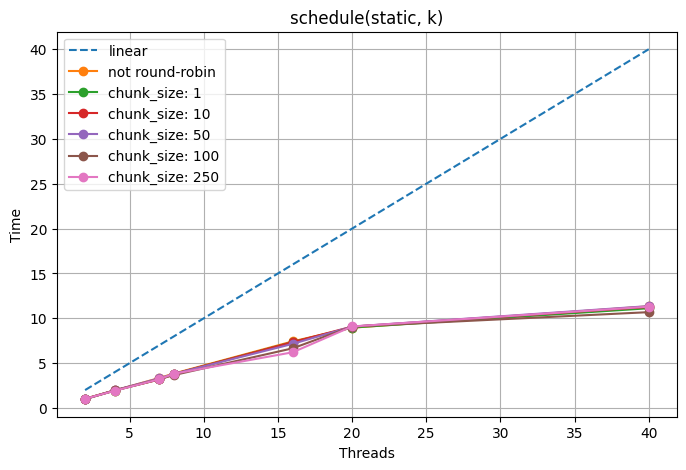

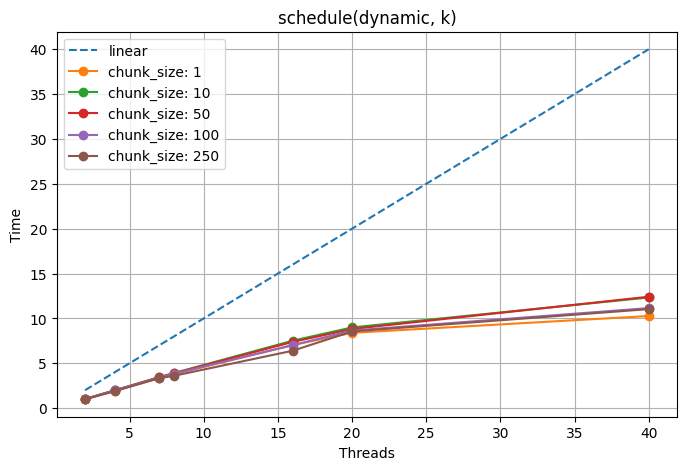

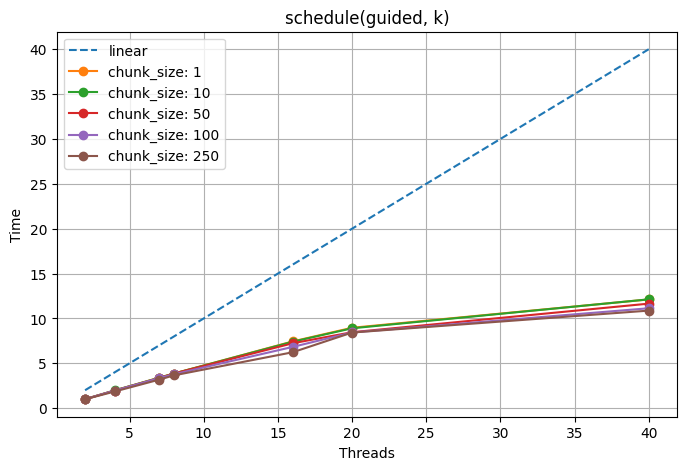

KeyError: 'efficiency'

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    df.columns = df.columns.str.strip()

    q10 = df.groupby(['threads', 'chunks'])['time'].transform(lambda x: x.quantile(0.1))
    q90 = df.groupby(['threads', 'chunks'])['time'].transform(lambda x: x.quantile(0.9))

    df = df[(df['time'] >= q10) & (df['time'] <= q90)]
    df = df.groupby(['threads', 'chunks'])['time'].mean().reset_index()

    return df

df_static = pd.read_csv('slae/slae_single_block.csv')
df_static_k = pd.read_csv('slae/slae_static_k.csv')
df_static.columns = df_static.columns.str.strip()
df_static_k.columns = df_static_k.columns.str.strip()
df_static['chunks'] = 0
df_static = df_static[df_static['threads'] != 1]
df_static = pd.concat([df_static, df_static_k])

df_dynamic = pd.read_csv('slae/slae_dynamic.csv')
df_guided = pd.read_csv('slae/slae_guided.csv')

df_static = prepare_data(df_static)
df_dynamic = prepare_data(df_dynamic)
df_guided = prepare_data(df_guided)

baseline = df_static[df_static['chunks'] == 0].set_index('threads')['time']

# def build_plot(df, baseline, title):

#     df['ratio'] = df['time'] / df['threads'].map(baseline)

#     #plot
#     plt.figure(figsize=(8, 5))

#     for c, group in df.groupby('chunks'):
#         if c != 0:
#             plt.plot(group['threads'], group['ratio'], marker='o', label=f'k = {c}')

#     plt.axhline(1.0, linestyle='--', color='red', label='schedule(static)')

#     plt.xlabel('Threads')
#     plt.ylabel('Time ratio')
#     plt.title(title)
#     plt.legend()
#     plt.grid(True)

#     plt.show()

def build_plot(df, title):

    df['speedup'] = df['time'].transform(lambda x: x.iloc[0] / x)

    

    #plot
    plt.figure(figsize=(8, 5))

    # идеальная линейная линия
    threads = sorted(df['threads'].unique())
    ideal = threads  # S(p) = p
    plt.plot(threads, ideal, linestyle='--', label='linear')

    for c, group in df.groupby('chunks'):
        if c == 0:
            plt.plot(group['threads'], group['speedup'], marker='o', label='not round-robin')
        else:
            plt.plot(group['threads'], group['speedup'], marker='o', label=f'chunk_size: {c}')

    plt.xlabel('Threads')
    plt.ylabel('Time')
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.show()

# build_plot(df_static, baseline, 'schedule(static, k)')
# build_plot(df_dynamic, baseline, 'schedule(dynamic, k)')
# build_plot(df_guided, baseline, 'schedule(guided, k)')

build_plot(df_static, 'schedule(static, k)')
build_plot(df_dynamic, 'schedule(dynamic, k)')
build_plot(df_guided, 'schedule(guided, k)')

df_static = df_static[df_static['threads'] == 40]
row_static = df_static.loc[df_static['efficiency'].idxmax()]
print('Static best: ')
print(row_static)

df_dynamic = df_dynamic[df_dynamic['threads'] == 40]
row_dynamic = df_dynamic.loc[df_dynamic['efficiency'].idxmax()]
print('Dynamic best: ')
print(row_dynamic)

df_guided = df_guided[df_guided['threads'] == 40]
row_guided = df_guided.loc[df_guided['efficiency'].idxmax()]
print('Guided best: ')
print(row_guided)


# df.groupby('chunks')['ratio'].mean()

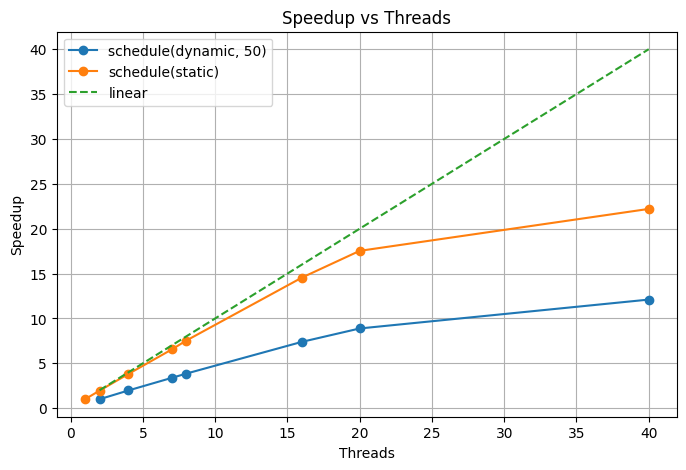

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_baseline = pd.read_csv('slae/slae_single_block.csv')
df_baseline.columns = df_baseline.columns.str.strip()
q10 = df_baseline.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
q90 = df_baseline.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))
df_baseline = df_baseline[(df_baseline['time'] >= q10) & (df_baseline['time'] <= q90)]
df_baseline = df_baseline.groupby('threads')['time'].mean().reset_index()
df_baseline['speedup'] = df_baseline['time'].transform(lambda x: x.iloc[0] / x)

df = pd.read_csv('slae/slae_guided.csv')
df.columns = df.columns.str.strip()
df = df[df['chunks'] == 10]

q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby('threads')['time'].mean().reset_index()
df['speedup'] = df['time'].transform(lambda x: x.iloc[0] / x)

# идеальная линейная линия
threads = sorted(df['threads'].unique())
ideal = threads  # S(p) = p

# plot
plt.figure(figsize=(8, 5))

plt.plot(df['threads'], df['speedup'], marker='o', label='schedule(dynamic, 50)')
plt.plot(df_baseline['threads'], df_baseline['speedup'], marker='o', label='schedule(static)')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()